# Reflection Spectra over Frequencies for Radar Design

In this example, we reproduce the result of Fig. 8 in the work [1].

[1] Eric Michielssen, Jean-Michel Sajer, S. Ranjithan, and Raj Mittra. [Design of lightweight, broad-band microwave absorbers using genetic algorithms](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=238519&casa_token=cAzTLiuvjPcAAAAA:iW8Ema9V9aE9lUAGOst4mGaeFeh45hGqOAJY1-ieAXdYcAqUmrNo1d3PpHUrecssvVvZzWK6rg&tag=1). *IEEE Transactions on Microwave Theory and Techniques*, vol. 41, no. 6, pp. 1024–1031, 1993.

First, the required packages are imported.

In [55]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as onp

import jaxlayerlumos as jll
import jaxlayerlumos.utils_materials as jll_utils_materials
import jaxlayerlumos.utils_units as jll_utils_units

We define frequencies from 0.1 GHz to 10 GHz and an incidence angle 0

In [56]:
freq_range = (0.1, 10)
inc_angle = 0

frequencies = jnp.linspace(freq_range[0] * jll_utils_units.get_giga(), freq_range[1] * jll_utils_units.get_giga(), 1000)
frequencies_in_ghz = onp.array(frequencies) / jll_utils_units.get_giga()

Radar designs suggested in the work [1] in Table II are specified. Then, the details of four radar designs are printed.

In [57]:
designs = [
    {
        "materials_data": ["14", "6", "10", "13", "6"],
        "thicknesses_in_mm": [0.399, 2.202, 1.740, 0.423, 0.384],
        "ref_R_in_db": -20
    },
    {
        "materials_data": ["14", "6", "10", "13", "6"],
        "thicknesses_in_mm": [0.399, 2.202, 1.740, 0.423, 0.384],
        "ref_R_in_db": -20
    },
    {
        "materials_data": ["16", "6", "5", "11", "2"],
        "thicknesses_in_mm": [0.486, 1.446, 1.272, 0.885, 1.155],
        "ref_R_in_db": -23.5
    },
    {
        "materials_data": ["14", "6", "10", "13", "6"],
        "thicknesses_in_mm": [0.486, 1.446, 1.272, 0.885, 1.155],
        "ref_R_in_db": -16
    }
]

# Define custom names for the designs
design_names = ["TMH 1, 0 degrees", "TMH 2, 40 degrees", "HF 1, 0 degree", "HF 2, 40 degrees"]

for i, design in enumerate(designs):
    materials_data = design["materials_data"]
    thicknesses_in_mm = design["thicknesses_in_mm"]
    ref_R_in_db = design["ref_R_in_db"]

    materials = ["Air"] + materials_data + ["PEC"]
    thicknesses = jnp.array([0.0] + [thickness * jll_utils_units.get_milli() for thickness in thicknesses_in_mm] + [0.0])

    print(f"{design_names[i]}:")
    print("  Material layout:", materials)
    print("  Layer thicknesses (m):", thicknesses)
    print("  Reference R (db):", ref_R_in_db)


TMH 1, 0 degrees:
  Material layout: ['Air', '14', '6', '10', '13', '6', 'PEC']
  Layer thicknesses (m): [0.       0.000399 0.002202 0.00174  0.000423 0.000384 0.      ]
  Reference R (db): -20
TMH 2, 40 degrees:
  Material layout: ['Air', '14', '6', '10', '13', '6', 'PEC']
  Layer thicknesses (m): [0.       0.000399 0.002202 0.00174  0.000423 0.000384 0.      ]
  Reference R (db): -20
HF 1, 0 degree:
  Material layout: ['Air', '16', '6', '5', '11', '2', 'PEC']
  Layer thicknesses (m): [0.       0.000486 0.001446 0.001272 0.000885 0.001155 0.      ]
  Reference R (db): -23.5
HF 2, 40 degrees:
  Material layout: ['Air', '14', '6', '10', '13', '6', 'PEC']
  Layer thicknesses (m): [0.       0.000486 0.001446 0.001272 0.000885 0.001155 0.      ]
  Reference R (db): -16


In the next cell, we compare our results to the reference results.

In [58]:
Rs_in_db = []
ref_Rs_in_db = []

design_names = ["TMH 1, 0", "TMH 2, 40", "HF 1, 0", "HF 2, 40"]
inc_angles = [0, 40, 0, 40]

for i, design in enumerate(designs):
    materials_data = design["materials_data"]
    thicknesses_in_mm = design["thicknesses_in_mm"]
    ref_R_in_db = design["ref_R_in_db"]
    inc_angle = inc_angles[i]

    materials = ["Air"] + materials_data + ["PEC"]
    thicknesses = jnp.array([0.0] + [thickness * jll_utils_units.get_milli() for thickness in thicknesses_in_mm] + [0.0])

    eps_stack, mu_stack = jll_utils_materials.get_eps_mu(materials, frequencies)
    R_TE, _, R_TM, _ = jll.stackrt_eps_mu(eps_stack, mu_stack, thicknesses, frequencies, inc_angle)
    R = (R_TE + R_TM) / 2.0
    R_in_db = 10 * jnp.log10(R).squeeze()

    print(f"{design_names[i]} (inc_angle = {inc_angle}°): max(R_in_db) {onp.max(R_in_db):.2f} ref_R_in_db {ref_R_in_db:.2f}")
    Rs_in_db.append(R_in_db)
    ref_Rs_in_db.append(ref_R_in_db)

Rs_in_db = onp.array(Rs_in_db)
ref_Rs_in_db = onp.array(ref_Rs_in_db)


TMH 1, 0 (inc_angle = 0°): max(R_in_db) -0.52 ref_R_in_db -20.00
TMH 2, 40 (inc_angle = 40°): max(R_in_db) -0.54 ref_R_in_db -20.00
HF 1, 0 (inc_angle = 0°): max(R_in_db) -5.77 ref_R_in_db -23.50
HF 2, 40 (inc_angle = 40°): max(R_in_db) -0.42 ref_R_in_db -16.00


The results of reflection spectra over frequencies are plotted.

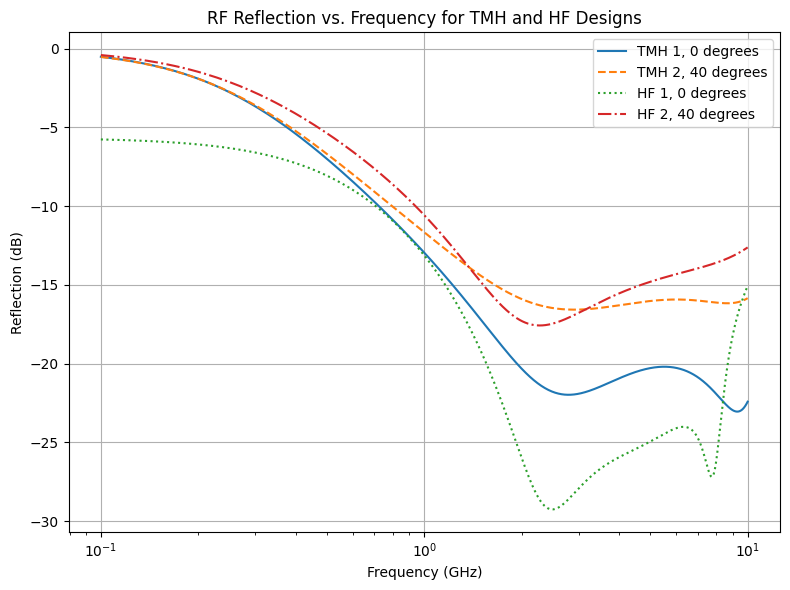

In [59]:
fig = plt.figure(figsize=(8, 6))
ax = fig.gca()
line_styles = ['-', '--', ':', '-.']

design_names = ["TMH 1, 0 degrees", "TMH 2, 40 degrees", "HF 1, 0 degrees", "HF 2, 40 degrees"]

for i, (R_in_db, ref_R_in_db) in enumerate(zip(Rs_in_db, ref_Rs_in_db)):
    ax.semilogx(
        frequencies_in_ghz,
        onp.array(R_in_db),
        line_styles[i % len(line_styles)], 
        label=design_names[i]
    )

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflection (dB)")
ax.set_title("RF Reflection vs. Frequency for TMH and HF Designs")
ax.grid()

plt.legend()
plt.tight_layout()
plt.show()
